# BIPN 162 Final Project Code Notebook
*title of project*

*Alton Gu, Margaret Jones, Laura Liang*

## idk delete if theres nothing we care to write 

* hi

## Setup
*Are there packages that need to be imported, or datasets that need to be downloaded?*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch import nn, optim

from sklearn import decomposition
from sklearn.datasets import fetch_openml

from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.layers import BatchNormalization, Dropout, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.losses import mse
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

import tensorflow as tf
tf.random.set_seed(42)

!pip install -q -U keras-tuner
from keras_tuner.tuners import Hyperband, BayesianOptimization
from keras import ops

import IPython

import shutil
import os

import scipy
from scipy import linalg as LA
from scipy.stats import pearsonr


In [56]:
print(f"Keras version: {keras.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")

print(f"Python version: {os.sys.version}")

Keras version: 3.13.2
TensorFlow version: 2.20.0
Pandas version: 2.3.3
Numpy version: 2.1.3
Scipy version: 1.16.3
Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]


In [ ]:
#checking metabolite data (Gomari paper replication)
qmdiab = pd.read_csv("QMDiab_metabolite_data.csv")
aml = pd.read_csv("AML_metabolite_data.csv")
schiz = pd.read_csv("Schizophrenia_metabolite_data.csv")

print(qmdiab.shape)
print(aml.shape)
print(schiz.shape)

print(qmdiab.columns[:10])
print(aml.columns[:10])
print(schiz.columns[:10])


## Data Wrangling

### [placeholder but new data set]

In [ ]:
df = pd.read_csv('GSE53697_RNAseq_AD.txt', delimiter='\t')
df.set_index('GeneSymbol', inplace=True)

# Isolates the RPKM, aka normalized data for analysis in a new dataframe.
rpkm_cols = [col for col in df.columns if '_rpkm' in col]
df_rpkm = df[rpkm_cols]


print(df_rpkm.head())
print(df_rpkm.shape) # There are 17 samples, and the expression levels of around 19,000 genes are measured.

In [ ]:
#Transpose the matrix so rows = genes and columns = samples
X = df_rpkm.T

print(X.shape) #the 17 samples x 19185 genes are now oriented correctly
X.head()

In [ ]:
#Remove the genes with zero variance
X = X.loc[:, X.var() > 0]

#Log transform expression since RNA-seq expression is skewed
X = np.log1p(X)

#Select highly variable genes
gene_var = X.var(axis=0)
top_genes = gene_var.sort_values(ascending=False).head(2000).index
X = X[top_genes]

#Standardize features 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X.shape)

### Wrangling of Reference Dataset (Gomari et al.)

In [3]:
df_schizo = pd.read_csv('Schizophrenia_metabolite_data.csv')
df_schizo['Disease'] = 'Schizo'
df_AML = pd.read_csv('AML_metabolite_data.csv')
df_AML['Disease'] = 'AML'
df_diabetes = pd.read_csv('QMDiab_metabolite_data.csv')
df_diabetes['Disease'] = 'Diab'

combined_df = pd.concat([df_schizo, df_AML, df_diabetes], join='inner')
meta = combined_df[['Disease']]
combined_df_numeric = combined_df.drop(columns=['Disease'])
# combined_df_numeric = combined_df_numeric.drop(combined_df_numeric.index[0], axis=0) # Drop the first row which contains non-numeric values
combined_df_numeric = combined_df_numeric.astype(float) # Convert all values to float
print(combined_df.head())
print(combined_df.shape)

     M33228    M35186    M34214    M34419    M34395    M34389    M35628  \
0 -0.224790  0.367972  0.213836  0.034424 -0.563072 -0.822089 -0.043932   
1 -1.365763 -0.250218 -1.102545  0.106423  0.547012  0.831003 -0.235921   
2  1.361526  1.419471  0.095614  1.458757 -0.131300  0.118827  1.122446   
3 -1.129735 -0.605956 -0.677170 -0.660245  1.392298  1.474983 -0.627671   
4 -0.402553 -0.924436  0.203205  0.649445 -0.653498 -0.428191 -0.667663   

     M33230    M21127    M33955  ...    M37203    M35527    M37190    M37198  \
0  0.765081 -1.229083  0.376804  ...  0.668735 -1.156433  1.380834  1.028611   
1  0.485585 -0.849375  0.587461  ...  0.910195 -0.636947  1.442837 -0.200371   
2  0.505534 -0.656467  1.113982  ... -3.679084 -0.677344 -3.368232  1.096145   
3  0.034415 -1.640713 -0.864807  ...  0.551563 -1.768515  1.591040  1.499522   
4 -0.650306 -0.145957 -0.191565  ...  1.548937  1.241594  0.203979  2.095742   

     M38178    M39379    M38768    M37506    M37097  Disease  
0 -0.

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(combined_df_numeric, meta['Disease']):
    input_train, input_test = combined_df_numeric.iloc[train_index], combined_df_numeric.iloc[test_index]
    result_train, result_test = meta['Disease'].iloc[train_index], meta['Disease'].iloc[test_index]

print(f"Training set size: {len(input_train)}")
print(f"Testing set size: {len(input_test)}")

Training set size: 515
Testing set size: 129


# Confirmation of VAE Pipeline (Gomari et al.)

The parameter optimization and VAE code are directly copied from the Github attached to the paper. Minor tweaks were made to ensure that the code ran smoothly AND to cut down on runtime (in the interest of this project).

### Parameter Optimization

In [ ]:
# Data & model configuration
batch_size = 32
no_epochs = 1000 #lets keep it shorter for now haha
latent_dim = 18

original_dim = input_train.shape[1]
input_shape = (original_dim,)
# recommended to do this here: https://www.tensorflow.org/tutorials/keras/keras_tuner
class ClearTrainingOutput(tf.keras.callbacks.Callback):
    def on_train_end(*args, **kwargs):
     IPython.display.clear_output(wait = True)
        
        
def model_builder(hp):
    # # =================
    # # Encoder
    # # =================

    # Definition
    i       = Input(shape=input_shape, name='encoder_input')
    
    x       = Dense(hp.Int('encoder_units',
                           min_value=30,
                           max_value=150,
                           step=10))(i)
    x       = LeakyReLU(alpha=0.2)(x) # added alpha=0.2 to make it more aggressive, since we have a small dataset and want to avoid dying ReLUs
   
    
    mu      = Dense(latent_dim, name='latent_mu')(x)
    sigma   = Dense(latent_dim, name='latent_sigma')(x)

    # Define sampling with reparameterization trick
    def sample_z(args):
        mu, sigma = args
        batch     = ops.shape(mu)[0]
        dim       = ops.int_shape(mu)[1]
        eps       = keras.random.normal(shape=(batch, dim))
        return mu + ops.exp(sigma / 2) * eps

    # Use reparameterization trick to ....??
    z       = Lambda(sample_z, output_shape=(latent_dim, ), name='z')([mu, sigma])

    # Instantiate encoder
    encoder = Model(i, [mu, sigma, z], name='encoder')
    
    # =================
    # Decoder
    # =================

    # Definition
    d_i   = Input(shape=(latent_dim, ), name='decoder_input')
    
    x     = Dense(hp.Int('decoder_units',
                           min_value=20,
                           max_value=180,
                           step=10))(d_i)
    x     = LeakyReLU()(x)
        
    o     = Dense(original_dim)(x)

    # Instantiate decoder
    decoder = Model(d_i, o, name='decoder')
    
    # =================
    # VAE as a whole
    # =================
    beta = hp.Float('kl_beta', min_value=1e-4, max_value=1e-2, sampling='LOG', default=1e-3)
    # Define loss
    def kl_reconstruction_loss(true, pred):
      # Reconstruction loss
        reconstruction_loss = ops.mean(ops.square(true - pred), axis=-1)
        reconstruction_loss *= original_dim

        # 2. KL divergence loss 
        # REPLACE tf.exp or K.exp with ops.exp
        # REPLACE K.square with ops.square
        kl_loss = 1 + sigma - ops.square(mu) - ops.exp(sigma)
        kl_loss = ops.sum(kl_loss, axis=-1)
        kl_loss *= -0.5
        
        weighted_kl = kl_loss * beta

        return ops.mean(reconstruction_loss + weighted_kl)

    # Instantiate VAE
    vae_outputs = decoder(encoder(i)[2])
    vae         = Model(i, vae_outputs, name='vae')


    # Define optimizer
    optimizer = Adam(hp.Float(
        'learning_rate',
        min_value=1e-4,
        max_value=1e-2,
        sampling='LOG',
        default=1e-3
    ))

    
    # Use a basic string for the optimizer and loss to avoid 
    # complex objects that trigger the 'experimental' flags
    vae.compile(
        optimizer='adam', 
        loss='mse',
        metrics=['mse']
    )
    
    # Manually set this to True to bypass the 'must call compile' check
    vae.compiled = True 
    
    return vae
    
# Set tuner parameters
tuner = Hyperband(
    model_builder,
    objective='mse',
    # Original is 2, upping to 3 to make tuning more aggressive and faster, since we have a lot of hyperparameters to tune and a small dataset
    factor=2,
    # Decreasing max_epochs in the interest of time
    max_epochs=50,
    directory='hyperband_optimization',
    project_name='gomari_vae',
    overwrite=True)
tuner.search_space_summary()
# Run Tuner
# Runtime on MacBook Pro 2017: 01h 15m

Search space summary
Default search space size: 4
encoder_units (Int)
{'default': None, 'conditions': [], 'min_value': 30, 'max_value': 150, 'step': 10, 'sampling': 'linear'}
decoder_units (Int)
{'default': None, 'conditions': [], 'min_value': 20, 'max_value': 180, 'step': 10, 'sampling': 'linear'}
kl_beta (Float)
{'default': 0.001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
learning_rate (Float)
{'default': 0.001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
(515, 162)
(129, 162)


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [7]:
X_train_numeric = input_train.astype('float32').values
X_test_numeric = input_test.astype('float32').values
X_train_pure = np.array(input_train.values, dtype='float32')
X_test_pure  = np.array(input_test.values, dtype='float32')

print(X_train_pure.shape)
print(X_test_pure.shape)

(515, 162)
(129, 162)


In [ ]:
tuner.search(
    x=X_train_pure, 
    y=X_train_pure, # Target is the INPUT
    validation_data=(X_test_pure, X_test_pure),
    epochs=10
)
# Print out best tuned parameters
tuner.results_summary(num_trials = 2)
tuner.get_best_models()[0].summary()
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]

print(best_hps.get('encoder_units'))
print(best_hps.get('decoder_units'))
print(best_hps.get('learning_rate'))
print(best_hps.get('kl_beta'))


In [2]:
folder_to_clean = 'hyperband_optimization'

if os.path.exists(folder_to_clean):
    shutil.rmtree(folder_to_clean)

### Gomari et al.'s Code for PCA and VAE

In [5]:
def PCA(data):
    
    data_raw = data
    #centering the data
    data -= np.mean(data, axis = 0)  

    cov = np.cov(data, rowvar = False)

    evals , evecs = LA.eigh(cov)

    # sort the eigenvalues (and eigenvectors accordingly) descending
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    
    # sort the eigenvectors
    S = evecs[:,idx]
    
    A = np.dot(data, S) 
    
    np.testing.assert_array_almost_equal(np.matmul(A, LA.inv(S)), data_raw)
    
    # calculate loadings of each PCA component
    loadings = S * np.sqrt(evals)
    
    return([A, S, loadings])

    

class PCA_model:
    
    def __init__(self, reference_data, k):
        self.reference_data = reference_data
        self.k = k
        self.A, self.S, self.loadings = PCA(self.reference_data)
    
    def encode(self, target_data):

        # PCA encode target_data
        A2 = np.dot(target_data, self.S) 

        return(A2[:,:self.k])
    
    def reconstruct(self, target_data):

        # PCA encode target_data
        A2 = np.dot(target_data, self.S) 
        
        # reconstruct target_data based on learned S
        Xrec = np.matmul(A2[:, :self.k], LA.inv(self.S)[:self.k, ]) # Note: S.T == LA.inv(S) in this case, since eigen-vector matrix

        return(Xrec)
    
    def get_loadings(self):
        
        return(self.loadings[:,:self.k])



def KPCA(data, k, kernel, alpha, gamma, coef0, degree):

    data_raw = data
    
    #centering the data
    data -= np.mean(data, axis = 0)  

    kPCA = KernelPCA(n_components = k, kernel=kernel, alpha=alpha, gamma=gamma, coef0=coef0, degree=degree, fit_inverse_transform=True)

    kPCA.fit(data)
    
    return kPCA


class KPCA_model:
    
    def __init__(self, reference_data, k, kernel, alpha, gamma, coef0, degree):
        self.reference_data = reference_data
        self.k = k
        self.kernel= kernel
        self.alpha = alpha
        self.gamma = gamma
        self.coef0 = coef0 
        self.degree = degree
        self.model = KPCA(self.reference_data, self.k, self.kernel, self.alpha, self.gamma, self.coef0, self.degree)
    
    def encode(self, target_data):

        # KPCA transform target_data
        A2 = self.model.transform(target_data) 

        return(A2)
    
    def reconstruct(self, target_data):

        encoded = self.encode(target_data)

        return self.model.inverse_transform(encoded)

class Sampling(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Creating a seed generator handles the "seed must have shape [2]" error
        self.seed_generator = keras.random.SeedGenerator(42)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        
        # Use the seed_generator to keep TensorFlow happy
        epsilon = keras.random.normal(
            shape=(batch, dim), 
            seed=self.seed_generator
        )
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon

class mtVAE():

    def __init__(self,
                input_shape,
                intermediate_dim,
                latent_dim,
                kl_beta=1e-2,
                learning_rate=1e-3):
        
        self.input_shape = input_shape
        self.intermediate_dim = intermediate_dim
        self.latent_dim = latent_dim
        self.kl_beta = kl_beta
        self.learning_rate = learning_rate
        
        # # =================
        # # Encoder
        # # =================

        # Definition
        self.input   = Input(shape=(self.input_shape,), name='encoder_input')
        self.x       = Dense(self.intermediate_dim)(self.input)
        self.x       = LeakyReLU()(self.x)


        self.mu      = Dense(self.latent_dim, name='latent_mu')(self.x)
        self.sigma   = Dense(self.latent_dim, name='latent_sigma')(self.x)
       
        # Define sampling with reparameterization trick
       
        self.z = Sampling()([self.mu, self.sigma])
        # Instantiate encoder
        self.encoder = Model(self.input, [self.mu, self.sigma, self.z], name='encoder')

        # =================
        # Decoder
        # =================

        # Definition
        self.decoder_input   = Input(shape=(self.latent_dim, ), name='decoder_input')
        self.x     = Dense(self.intermediate_dim)(self.decoder_input)
        self.x     = LeakyReLU()(self.x)

        self.output  = Dense(self.input_shape)(self.x)

        # Instantiate decoder
        self.decoder = Model(self.decoder_input, self.output, name='decoder')

        # =================
        # VAE as a whole
        # =================

        # Instantiate VAE
        self.vae_outputs = self.decoder(self.encoder(self.input)[2])
        self.vae         = Model(self.input, self.vae_outputs, name='vae')

        def compute_kl(args):
            mu, sigma = args
            kl_loss = -0.5 * ops.sum(1 + sigma - ops.square(mu) - ops.exp(sigma), axis=-1)
            return ops.mean(kl_loss)

        kl_val = keras.layers.Lambda(
        lambda x: x, # Just pass data through
        activity_regularizer=lambda x: compute_kl([self.mu, self.sigma]) * self.kl_beta,
        name='kl_loss_layer'
        )([self.mu, self.sigma])

        # Define optimizer
        self.optimizer = Adam(learning_rate=self.learning_rate)
        
        # Define loss
        def kl_reconstruction_loss(true, pred):
            # Reconstruction loss
            reconstruction_loss = mse(true, pred)
            reconstruction_loss *= self.input_shape

            # KL divergence loss
            kl_loss = 1 + self.sigma - ops.square(self.mu) - ops.exp(self.sigma)
            kl_loss = ops.sum(kl_loss, axis=-1)
            kl_loss *= -0.5

            # Total loss = 50% rec + 50% KL divergence loss
            return ops.mean(reconstruction_loss + self.kl_beta*kl_loss)

        # Compile VAE
        self.vae.compile(optimizer=self.optimizer, loss='mse')
    
    
    def train(self, train_data, val_data, n_epochs, batch_size, verbosity=2):
        
        self.vae.fit(train_data, train_data,
                     epochs = n_epochs, 
                     batch_size = batch_size, 
                     validation_data = (val_data, val_data),
                     verbose = verbosity)
    
    def encode(self, data):
        return self.encoder.predict(data)[2]
    
    def encode_mu(self, data):
        return self.encoder.predict(data)[0]
    
    def decode(self, data):
        return self.decoder.predict(data)
    
    def reconstruct(self, data):
        return self.decode(self.encode(data))
    
    def save_model(self, save_folder):
        
        vae_path     = save_folder + 'VAE.h5'
        encoder_path = save_folder + 'VAE_encoder.h5'
        decoder_path = save_folder + 'VAE_decoder.h5'
        
        self.vae.save(vae_path)
        self.encoder.save(encoder_path)
        self.decoder.save(decoder_path)
        
    
    def load_vae(self, save_path):

        # The two functions below have to be redefined for the loading
        # of the model. They cannot be methods of the mtVAE class for
        # some reason.
        # https://github.com/keras-team/keras/issues/13992
        
        # Define sampling with reparameterization trick
        def sample_z(args):
            mu, sigma = args
            batch     = ops.shape(mu)[0]
            dim       = ops.shape(mu)[1]
            eps       = keras.random.normal(shape=[batch, dim])
            return mu + ops.exp(sigma / 2) * eps
        
                # Define loss
        def kl_reconstruction_loss(true, pred):
            # Reconstruction loss
            reconstruction_loss = mse(true, pred)
            reconstruction_loss *= self.input_shape

            # KL divergence loss
            kl_loss = 1 + self.sigma - ops.square(self.mu) - ops.exp(self.sigma)
            kl_loss = ops.sum(kl_loss, axis=-1)
            kl_loss *= -0.5

            # Total loss = 50% rec + 50% KL divergence loss
            return K.mean(reconstruction_loss + self.kl_beta*kl_loss)
        
        keras.losses.kl_reconstruction_loss = kl_reconstruction_loss
        self.vae = keras.models.load_model(save_path)
        self.vae.compile(optimizer=self.optimizer, 
                         custom_objects={'sample_z': sample_z}, 
                         loss=kl_reconstruction_loss, 
                         metrics = ['mse'])
        
    def load_encoder(self, save_path):
        self.encoder = keras.models.load_model(save_path)
        
    def load_decoder(self, save_path):
        self.decoder = keras.models.load_model(save_path)

### Metric Measurements

In [7]:
def get_correlations(x1, x2, rowwise = True):

    if rowwise:
        cors = [pearsonr(x1[idx,], x2[idx,])[0] for idx in range(x1.shape[0])]
    else:
        cors = [pearsonr(x1[:,idx], x2[:,idx])[0] for idx in range(x1.shape[1])]

    return(cors)


def get_mse(A, B, rowwise = True):

    if rowwise:
        ax = 0
        mse = ((A - B)**2).mean(axis=ax)
    else:
        ax = 1
        mse = ((A - B)**2).mean(axis=ax)

    return(mse)


def get_mae(A, B, rowwise = True):

    if rowwise:
        ax = 0
        mae = np.abs(A - B).mean(axis=ax)
    else:
        ax = 1
        mae = np.abs(A - B).mean(axis=ax)

    return(mae)
        

def matrix_cor(x, y):

    return np.corrcoef(np.corrcoef(x, rowvar = False).flatten(), np.corrcoef(y, rowvar = False).flatten())[0,1]


def matrix_mse(x, y):
    
    mses = get_mse(np.corrcoef(x, rowvar = False).flatten(), np.corrcoef(y, rowvar = False).flatten())
    return np.mean(mses)

def matrix_mae(x, y):
    
    maes = get_mae(np.corrcoef(x, rowvar = False).flatten(), np.corrcoef(y, rowvar = False).flatten())
    return np.mean(maes)

### VAE Training

In [8]:
input_dim = X_train_pure.shape[1]
intermediate_dim = 50
latent_dim = 18

kl_beta = 1e-2
learning_rate = 1e-3

batch_size = 32
n_epochs = 1000 # default is 1000

# instantiate model
mtmodel = mtVAE(int(input_dim),
                int(intermediate_dim),
                int(latent_dim),
                float(kl_beta),
                float(learning_rate))

mtmodel.train(X_train_pure, X_test_pure, n_epochs, batch_size)

Epoch 1/1000
17/17 - 1s - 40ms/step - loss: 1.8702 - val_loss: 1.5394
Epoch 2/1000
17/17 - 0s - 3ms/step - loss: 1.5964 - val_loss: 1.4294
Epoch 3/1000
17/17 - 0s - 3ms/step - loss: 1.4747 - val_loss: 1.3305
Epoch 4/1000
17/17 - 0s - 3ms/step - loss: 1.3618 - val_loss: 1.2506
Epoch 5/1000
17/17 - 0s - 3ms/step - loss: 1.2697 - val_loss: 1.1725
Epoch 6/1000
17/17 - 0s - 3ms/step - loss: 1.1917 - val_loss: 1.1145
Epoch 7/1000
17/17 - 0s - 3ms/step - loss: 1.1288 - val_loss: 1.0643
Epoch 8/1000
17/17 - 0s - 3ms/step - loss: 1.0751 - val_loss: 1.0218
Epoch 9/1000
17/17 - 0s - 3ms/step - loss: 1.0317 - val_loss: 0.9933
Epoch 10/1000
17/17 - 0s - 3ms/step - loss: 0.9950 - val_loss: 0.9597
Epoch 11/1000
17/17 - 0s - 3ms/step - loss: 0.9606 - val_loss: 0.9385
Epoch 12/1000
17/17 - 0s - 3ms/step - loss: 0.9305 - val_loss: 0.9153
Epoch 13/1000
17/17 - 0s - 3ms/step - loss: 0.9036 - val_loss: 0.8947
Epoch 14/1000
17/17 - 0s - 3ms/step - loss: 0.8831 - val_loss: 0.8739
Epoch 15/1000
17/17 - 0s - 3

### PCA and VAE Comparisons

In [57]:
input_train_val = X_train_pure
input_test_val  = X_test_pure
######################
# Define PCA model
######################
PCA_model_ = PCA_model(input_train_val, latent_dim)
# Generate TwinsUK dataset reconstructions with VAE and PCA
VAE_train = mtmodel.reconstruct(input_train_val)
VAE_test  = mtmodel.reconstruct(input_test_val)

PCA_train = PCA_model_.reconstruct(input_train_val)
PCA_test  = PCA_model_.reconstruct(input_test_val)
# Calculate sample-wise MSEs
test_mses       = np.mean(get_mse(VAE_test,  input_test_val))
train_mses      = np.mean(get_mse(VAE_train, input_train_val))
test_mses_pca   = np.mean(get_mse(PCA_test,  input_test_val))
train_mses_pca  = np.mean(get_mse(PCA_train, input_train_val))


print('==================== Sample-wise ============================')
print('======================= MSEs ================================')
print('\t \t \t VAE \t \t \t PCA')
print('Input train:\t ',  train_mses, '\t ', train_mses_pca)
print('Input test:\t ',   test_mses,  '\t ', test_mses_pca)
print('')
print('')


# Calculate correlation matrix MSEs (i.e. CM-MSEs)
test_mses  = matrix_mse(VAE_test,  input_test_val)
train_mses = matrix_mse(VAE_train, input_train_val)

test_mses_pca  = matrix_mse(PCA_test,  input_test_val)
train_mses_pca = matrix_mse(PCA_train, input_train_val)

print('================= Correlation Matrix ========================')
print('======================= MSEs ================================')
print('\t \t \t VAE \t \t \t PCA')
print('Input train:\t ',  train_mses, '\t ', train_mses_pca)
print('Input test:\t ',   test_mses, '\t ',  test_mses_pca)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
==================== Sample-wise ============================
======================= MSEs ================================
	 	 	 VAE 	 	 	 PCA
Input train:	  0.58489424 	  0.5890329731338401
Input test:	  0.8794083 	  0.6259892308652588


================= Correlation Matrix ========================
======================= MSEs ================================
	 	 	 VAE 	 	 	 PCA
Input train:	  0.009320721386617426 	  0.020068482960813247
Input test:	  0.020757596551497934 	  0.0332022357545823


# Data Analysis

### Analysis using PCA

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

### SHAP ANALYSIS [testing]

In [1]:
import shap 
from shap.explainers._deep.deep_tf import op_handlers


In [ ]:
# 1. Define a clean wrapper function
# This takes a numpy array of inputs and returns only the 'mu' (latent means)
def predict_mu(x):
    # We use verbose=0 to stop Keras progress bars from flooding the screen
    return mtmodel.encoder.predict(x.astype('float32'), verbose=0)[0]

# 2. Summarize the background data
# This is crucial! It reduces your 100 background samples into 10 'centroids'
# This makes KernelExplainer 10x faster while keeping the logic sound.
background_summary = shap.kmeans(X_train_pure[:100], 10)

# 3. Initialize the Explainer
# We pass the function, not the model object
explainer = shap.KernelExplainer(predict_mu, background_summary)

# 4. Calculate SHAP values for a small subset
# Start with 5-10 samples to ensure it runs without error
test_subset = X_test_pure[:10].astype('float32')
shap_values = explainer.shap_values(test_subset)



  0%|          | 0/10 [00:00<?, ?it/s]

In [14]:
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"List length: {len(shap_values)}")
    print(f"Shape of first element: {np.array(shap_values[0]).shape}")
else:
    print(f"Shape of array: {shap_values.shape}")
print(f"Shape of test_subset: {test_subset.shape}")

Type of shap_values: <class 'numpy.ndarray'>
Shape of array: (10, 162, 18)
Shape of test_subset: (10, 162)


Plotting Latent Dim 0
SHAP shape: (10, 162), Data shape: (10, 162)


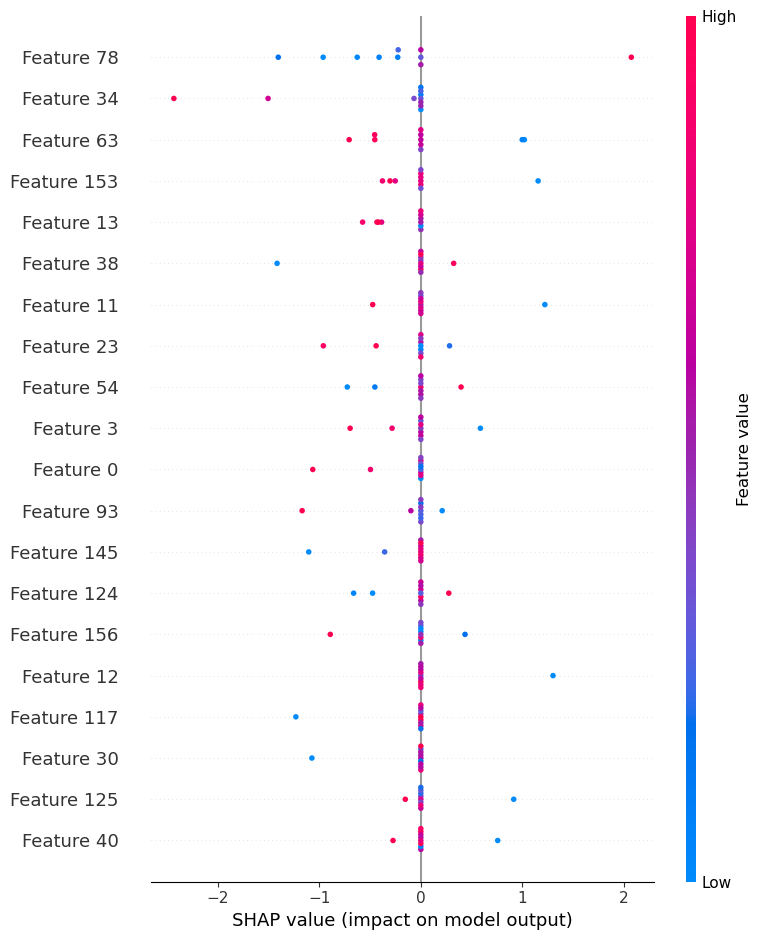

In [16]:
shap_raw = np.array(shap_values)

# 2. Transpose it to: (Latent_Dims, Samples, Features)
# This moves the 18 to the front
# New shape: (18, 10, 162)
shap_transposed = shap_raw.transpose(2, 0, 1)

# 3. Select the latent dimension you want to analyze (0 to 17)
latent_dim_to_explain = 0
to_plot = shap_transposed[latent_dim_to_explain] # This is now (10, 162)

# 4. Final Plot
print(f"Plotting Latent Dim {latent_dim_to_explain}")
print(f"SHAP shape: {to_plot.shape}, Data shape: {test_subset.shape}")
shap.summary_plot(to_plot, test_subset)